### Table of Contents

1. [Introduction](#1.-introduction)

2. [Data](#2.-data)

3. [Methodology](#3.-methodology)

4. [Data Pre-processing](#4.-data-pre-processing)

    4.1. [Raw Dataset Loading & Inspection](#4.1.-raw-dataset-loading--inspection)

    4.2. [Conversion of WDI Dataset to Wide-format Panel Data](#4.2.-conversion-of-wdi-dataset-to-wide-format-panel-data)

    4.3. [Panel Balance Check](#4.3.-panel-balance-check)

    4.4. [Data Integrity Checks & Cleanup](#4.4.-data-integrity-checks--cleanup)

5. [Variable Transformations and Panel Data Prep](#5.-variable-transformations-and-panel-data-prep)

    5.1. [Variable Transformations](#5.1.-variable-transformations)

    5.2 [Missing Value Handling](#5.2.-missing-value-handling)

    5.3 [Sorting and Indexing Panel Data](#5.3.-sorting-and-indexing-panel-data)

    5.4 [Multicollinearity Check (VIF)](#5.4.-multicollinearity-check-vif)

6. [Econometric Modeling](#6.-econometric-modeling)

    6.1 [Pooled OLS (Baseline Reference Model)](#6.1.-pooled-ols-baseline-reference-model)

    6.2 [Entity Fixed Effects (FE) Model](#6.2.-entity-fixed-effects-fe-model)

    6.3 [Random Effects (RE) Model](#6.3.-random-effects-re-model)

    6.4 [Hausman Test (FE vs RE)](#6.4.-hausman-test-fe-vs-re)

    6.5 [Two-Way Fixed Effects (Entity + Year FE)](#6.5.-two-way-fixed-effects-entity--year-fe)

    6.6 [First Difference Panel Model](#6.6.-first-difference-panel-model)

7. [Results and Interpretation](#7.-results-and-interpretation)

    7.1. [EKC Turning Point Analysis](#7.1.-ekc-turning-point-analysis)

    7.2 [EKC Curve Visualization (Predicted $lnCO_2$ vs lnGDP)](#7.2.-ekc-curve-visualization-(predicted-lnco_2-vs-lngdp))

    7.3 [Year Fixed Effects Plot](#7.3.-year-fixed-effects-plot)

    7.4 [Year Fixed Effects Plot (Normalized)](#7.4.-year-fixed-effects-plot-(normalized))

    7.5 [Coefficient Plot](#7.5.-coefficient-plot)

    7.6 [Actual vs Fitted Plot](#7.6.-actual-vs-fitted-plot)

    7.7 [First-order Autocorrelation in Idiosyncratic Errors](#7.7.-first-order-autocorrelation-in-idiosyncratic-errors)

    7.8 [Woolridge Test for Serial Correlation](#7.8.-woolridge-test-for-serial-correlation)

    7.9 [Breusch-Pagan Test for Heteroskedasticity](#7.9.-breusch-pagan-test-for-heteroskedasticity)

### 1. Introduction

**Research Question**  
Do countries’ economic growth and structural change explain variation in carbon dioxide emissions per capita? Does an increase in GDP per capita result in higher level of emissions?

**Motivation**    
While rapid industrial expansion and urbanization have boosted the global economy, they have introduced significant sustainability risks. Furthermore, as emerging factors like Digital and AI waste pose unprecedented risks, finding the balance between growth and sustainability is central to today’s economic policy debate. The subject of this research links macroeconomic performance and environmental outcomes while associating structural shifts for explainability.

**Background and Existing Findings**  
Simon Kuznets researched the relationship between a nation’s growth and its environmental effect, popularly known as the Environmental Kuznets Curve (EKC). Numerous studies in Environmental Economics have established an inverted-U relationship between GDP and emissions. However, results can vary depending on the class of pollutants, time periods, and country groups. Recent studies suggest that structural variables and energy composition may alter the growth-emission relationship, hence the scope for an updated assessment.

### 2. Data

We are using a balanced panel from the World Bank’s World Development Indicators database for all available countries between 2000 and 2022. The dataset will combine measures of CO₂ emissions, GDP per capita, trade, industrial value added (as a percentage of GDP), energy use, shares of renewable and fossil-fuel energy, urban population, and population density.

[World Bank World Development Indicators (WDI) Panel Data 2000-2022](https://github.com/priyadarshanparida/kuznets-hypothesis-growth-vs-sustainability-buan6312/blob/main/data/panel_raw_wdi_2000_2022.csv)

### 3. Methodology

We hypothesize CO₂ emissions per capita to initially rise with income and later decline as economies diversify and adopt cleaner energy sources – a pattern consistent with the Environmental Kuznets Curve. The economic research will estimate a linear model including income and emissions to capture the EKC shape with the coefficient on GDP being our parameter of interest. Panel fixed-effects estimation will be used to control for unobserved, time-invariant country characteristics.

### 4. Data Pre-processing

In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from linearmodels import PooledOLS
from linearmodels import PanelOLS
from linearmodels import RandomEffects
from linearmodels.panel import compare
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

##### 4.1 Raw Dataset Loading & Inspection

In [64]:
# Load dataset
# filepath = "../data/panel_raw_wdi_2000_2022.csv"
filepath = "../data/wdi_raw_panel.csv"
wdi_panel_raw = pd.read_csv(filepath)

# Basic structure checks
print(f"Dataset Shape: {wdi_panel_raw.shape}    ")
print(f"Columns: {wdi_panel_raw.columns.tolist()}")
print(f"Sample Observations: {wdi_panel_raw.head()}")

Dataset Shape: (2394, 27)    
Columns: ['Country Name', 'Country Code', 'Series Name', 'Series Code', '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]', '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]']
Sample Observations:   Country Name Country Code  \
0  Afghanistan          AFG   
1  Afghanistan          AFG   
2  Afghanistan          AFG   
3  Afghanistan          AFG   
4  Afghanistan          AFG   

                                         Series Name           Series Code  \
0  Carbon dioxide (CO2) emissions excluding LULUC...  EN.GHG.CO2.PC.CE.AR5   
1                 GDP per capita (constant 2015 US$)        NY.GDP.PCAP.KD   
2       Energy use (kg of oil equivalent per capita)     EG.USE.P

##### 4.2 Conversion of WDI Dataset to Wide-format Panel Data

In [65]:
# 4.2.1 Melt the year columns (2000–2022) into a single Year column
wdi_panel_long = wdi_panel_raw.melt(
    id_vars=["Country Name", "Country Code", "Series Name", "Series Code"],
    var_name="Year",
    value_name="Value"
)

# Clean up the Year column to retain only the numeric year (e.g., "2000" from "2000 [YR2000]")
wdi_panel_long["Year"] = wdi_panel_long["Year"].str.extract(r"(\d{4})").astype(int)

# Convert Value to numeric
wdi_panel_long["Value"] = pd.to_numeric(wdi_panel_long["Value"], errors="coerce")

# Quick check of the structure
print("Shape after melting:", wdi_panel_long.shape)
print(f"Missingness Summary: {wdi_panel_long.isna().sum()}")

Shape after melting: (55062, 6)
Missingness Summary: Country Name       0
Country Code       0
Series Name        0
Series Code        0
Year               0
Value           5982
dtype: int64


In [66]:
# 4.2.2 Pivot indicators so each variable becomes its own column

# Pivot: each Series Code becomes a separate column
wdi_panel = wdi_panel_long.pivot_table(
    index=["Country Name", "Country Code", "Year"],
    columns="Series Code",
    values="Value"
).reset_index()

# Drop the pivot_table column index name
wdi_panel.columns.name = None

# Rename key indicators for clarity
rename_map = {
    "Country Name": "country_name",
    "Country Code": "country_code",
    "Year": "year",
    "EN.GHG.CO2.PC.CE.AR5": "co2_per_capita",
    "NY.GDP.PCAP.KD": "gdp_per_capita",
    "EG.USE.PCAP.KG.OE": "energy_use_per_capita",
    "SP.URB.TOTL.IN.ZS": "urban_pct",
    "NE.TRD.GNFS.ZS": "trade_pct_gdp",
    "EG.FEC.RNEW.ZS": "renewable_pct",
    "NV.IND.TOTL.ZS": "industry_value_added_pct_gdp",
    "EG.USE.COMM.FO.ZS": "fossil_fuel_pct",
    "EN.POP.DNST": "population_density"
}
wdi_panel.rename(columns=rename_map, inplace=True)

# Sort for clean panel structure
wdi_panel = wdi_panel.sort_values(["country_name", "year"]).reset_index(drop=True)

# Quick check
print("Shape after pivot:", wdi_panel.shape)
print(wdi_panel.head())

# Missingness summary after pivot
print("\nMissingness Summary (post-pivot):")
print(wdi_panel.isna().sum())

Shape after pivot: (6084, 12)
  country_name country_code  year  renewable_pct  fossil_fuel_pct  \
0  Afghanistan          AFG  2000        45.0000              NaN   
1  Afghanistan          AFG  2001        45.6000              NaN   
2  Afghanistan          AFG  2002        37.8000              NaN   
3  Afghanistan          AFG  2003        36.7000              NaN   
4  Afghanistan          AFG  2004        44.2000              NaN   

   energy_use_per_capita  co2_per_capita  population_density  trade_pct_gdp  \
0                    NaN          0.0505             30.8638            NaN   
1                    NaN          0.0466             31.0999            NaN   
2                    NaN          0.0441             32.7770            NaN   
3                    NaN          0.0443             34.8543            NaN   
4                    NaN          0.0379             36.1232            NaN   

   industry_value_added_pct_gdp  gdp_per_capita  urban_pct  
0                  

##### 4.3 Panel Balance Check

In [67]:
def check_panel_balance(df, country_col="country_name", year_col="year", n_sample=5):
    """
    Prints panel balance diagnostics for any country–year panel DataFrame.
    """
    # Basic counts
    print(f"Unique Countries: {df[country_col].nunique()}")
    print(f"Unique Years: {df[year_col].nunique()}")
    print(f"Year Range: {df[year_col].min()} — {df[year_col].max()}")

    # Expected vs actual
    expected_obs = df[country_col].nunique() * df[year_col].nunique()
    print(f"Expected Observations (if balanced): {expected_obs}")
    print(f"Actual Observations: {df.shape[0]}")

    # Observations per country
    country_year_counts = (
        df.groupby(country_col)[year_col]
        .nunique()
        .sort_values()
    )
    print("\nCountries with the fewest years of data:")
    print(country_year_counts.head(10))

    print("\nCountries with the most years of data:")
    print(country_year_counts.tail(10))

    # Missing years per country
    all_years = set(df[year_col].unique())
    missing_years = {
        c: sorted(all_years - set(yrs))
        for c, yrs in df.groupby(country_col)[year_col].unique().items()
    }

    print(f"\nSample Missing Years for First {n_sample} Countries:")
    for c in list(missing_years.keys())[:n_sample]:
        print(c, ":", missing_years[c])


In [68]:
# 4.3 Panel Balance Check
check_panel_balance(wdi_panel)

Unique Countries: 265
Unique Years: 23
Year Range: 2000 — 2022
Expected Observations (if balanced): 6095
Actual Observations: 6084

Countries with the fewest years of data:
country_name
St. Martin (French part)    12
Afghanistan                 23
Mozambique                  23
Myanmar                     23
Namibia                     23
Nauru                       23
Nepal                       23
Netherlands                 23
New Caledonia               23
New Zealand                 23
Name: year, dtype: int64

Countries with the most years of data:
country_name
Ghana                                       23
Gibraltar                                   23
Greece                                      23
Greenland                                   23
Grenada                                     23
Guam                                        23
Guatemala                                   23
Guinea                                      23
Fragile and conflict affected situations    23
Zim

##### 4.4 Data Integrity Checks & Cleanup

In [69]:
# 4.4.1 Check for duplicate rows
duplicates = wdi_panel.duplicated(subset=["country_name", "year"], keep=False)
print(f"Number of duplicate country-year rows: {duplicates.sum()}")

# 4.4.2 Confirm uniqueness of country-year keys
unique_pairs = wdi_panel[["country_name", "year"]].drop_duplicates().shape[0]
print(f"Unique country-year pairs: {unique_pairs}")
print(f"Total rows: {wdi_panel.shape[0]}")

# 4.4.3 Negative values check
numeric_cols = [
    "co2_per_capita",
    "gdp_per_capita",
    "energy_use_per_capita",
    "population_density",
    "renewable_pct",
    "fossil_fuel_pct",
    "industry_value_added_pct_gdp",
    "trade_pct_gdp",
    "urban_pct"
]

negative_counts = (wdi_panel[numeric_cols] < 0).sum()
print("\nNegative values detected:")
print(negative_counts)

# 4.4.4 Check for unrealistic percentage values (>100)
pct_cols = [
    "renewable_pct",
    "fossil_fuel_pct",
    "industry_value_added_pct_gdp",
    "trade_pct_gdp",
    "urban_pct"
]

over_100_counts = (wdi_panel[pct_cols] > 100).sum()
print("\nPercentage columns with values > 100:")
print(over_100_counts)

# 4.4.5 Missingness summary (post-cleaning)
print(f"\nMissingness Summary (final pre-processing):\n{wdi_panel.isna().sum()}")
print(f"\nTotal missing cells: {wdi_panel.isna().sum().sum()}")

# Reorder columns for better readability
ordered_cols = [
    "country_name",
    "country_code",
    "year",
    "co2_per_capita",
    "gdp_per_capita",
    "energy_use_per_capita",
    "urban_pct",
    "trade_pct_gdp",
    "renewable_pct",
    "fossil_fuel_pct",
    "industry_value_added_pct_gdp",
    "population_density"
]

wdi_panel = wdi_panel[ordered_cols]
wdi_panel.columns

Number of duplicate country-year rows: 0
Unique country-year pairs: 6084
Total rows: 6084

Negative values detected:
co2_per_capita                  0
gdp_per_capita                  0
energy_use_per_capita           0
population_density              0
renewable_pct                   0
fossil_fuel_pct                 6
industry_value_added_pct_gdp    0
trade_pct_gdp                   0
urban_pct                       0
dtype: int64

Percentage columns with values > 100:
renewable_pct                      0
fossil_fuel_pct                    0
industry_value_added_pct_gdp       0
trade_pct_gdp                   1343
urban_pct                          0
dtype: int64

Missingness Summary (final pre-processing):
country_name                       0
country_code                       0
year                               0
renewable_pct                    374
fossil_fuel_pct                 1592
energy_use_per_capita           1519
co2_per_capita                   311
population_density     

Index(['country_name', 'country_code', 'year', 'co2_per_capita',
       'gdp_per_capita', 'energy_use_per_capita', 'urban_pct', 'trade_pct_gdp',
       'renewable_pct', 'fossil_fuel_pct', 'industry_value_added_pct_gdp',
       'population_density'],
      dtype='object')

In [70]:
# 4.4.6: Keep only codes that are true ISO-3 country codes recognized by WDI
print("Shape before filtering countries:", wdi_panel.shape)
print(f"Unique countries in the WDI dataset before filtering to valid ISO-3 codes: {wdi_panel['country_name'].nunique()}")
wdi_countries = wdi_panel[wdi_panel["country_code"].isin(
    pd.read_csv("../data/country-codes.csv")["ISO3166-1-Alpha-3"].dropna().unique()
)]
print("Shape after filtering countries:", wdi_countries.shape)
print(f"Unique countries in the WDI dataset after filtering to valid ISO-3 codes: {wdi_countries['country_name'].nunique()}")
# Countries dropped
print("Countries dropped during filtering:", set(wdi_panel["country_name"]) - set(wdi_countries["country_name"]))

Shape before filtering countries: (6084, 12)
Unique countries in the WDI dataset before filtering to valid ISO-3 codes: 265
Shape after filtering countries: (4934, 12)
Unique countries in the WDI dataset after filtering to valid ISO-3 codes: 215
Countries dropped during filtering: {'IBRD only', 'Small states', 'World', 'IDA blend', 'Fragile and conflict affected situations', 'Caribbean small states', 'Least developed countries: UN classification', 'Early-demographic dividend', 'Sub-Saharan Africa (IDA & IBRD countries)', 'Pacific island small states', 'Africa Western and Central', 'Euro area', 'Other small states', 'High income', 'IDA only', 'Sub-Saharan Africa', 'Middle East, North Africa, Afghanistan & Pakistan (excluding high income)', 'Post-demographic dividend', 'Low & middle income', 'Upper middle income', 'East Asia & Pacific (excluding high income)', 'East Asia & Pacific', 'Europe & Central Asia', 'Latin America & the Caribbean (IDA & IBRD countries)', 'European Union', 'IDA to

### 5. Variable Transformations and Panel Data Prep

##### 5.1 Variable Transformations

In [71]:
# 5.1.1 Log-transform positive continuous variables
log_vars = {
    "co2_per_capita": "lnCO2",
    "gdp_per_capita": "lnGDP",
    "energy_use_per_capita": "lnEnergy",
    "urban_pct": "lnUrban",
    "trade_pct_gdp": "lnTrade",
    "population_density": "lnPopDensity"
}

panel_df = wdi_countries.copy()

# Convert invalid values to NaN before logging
for src, tgt in log_vars.items():
    panel_df[tgt] = panel_df[src].apply(
        lambda x: np.log(x) if pd.notna(x) and x > 0 else np.nan
    )

# 5.1.2 Add GDP squared term
panel_df["lnGDP_sq"] = panel_df["lnGDP"] ** 2

# 5.1.3 Keep level variables as-is
level_vars = ["renewable_pct", "fossil_fuel_pct", "industry_value_added_pct_gdp"]

print(f"Panel data columns: {panel_df.columns}")

Panel data columns: Index(['country_name', 'country_code', 'year', 'co2_per_capita',
       'gdp_per_capita', 'energy_use_per_capita', 'urban_pct', 'trade_pct_gdp',
       'renewable_pct', 'fossil_fuel_pct', 'industry_value_added_pct_gdp',
       'population_density', 'lnCO2', 'lnGDP', 'lnEnergy', 'lnUrban',
       'lnTrade', 'lnPopDensity', 'lnGDP_sq'],
      dtype='object')


##### 5.2 Missing Value Handling

In [72]:
print("Missing Value Handling (Revised)")
print(f"Initial dataset shape: {panel_df.shape}")
print(f"Unique countries: {panel_df['country_name'].nunique()}")
print(f"Years covered: {panel_df['year'].min()} to {panel_df['year'].max()}")

# 5.2.1: Inspect how many years each country has (raw availability)
before_dropping_missing_obs = panel_df["country_name"].unique()
country_year_counts = panel_df.groupby("country_name")["year"].nunique()

print("\nCountries with very sparse data (<=5 years):")
print(country_year_counts[country_year_counts <= 5])

# Drop countries with insufficient variation for FE models (<=5 years)
sparse_countries = country_year_counts[country_year_counts <= 5].index
panel_df = panel_df[~panel_df["country_name"].isin(sparse_countries)]

print(f"\nAfter removing sparse countries (<=5 years): {panel_df.shape}")
print(f"Remaining countries: {panel_df['country_name'].nunique()}")

# 5.2.2: Drop rows missing core variables (required for FE estimation)
core_vars = [
    "lnCO2","lnGDP","lnGDP_sq","lnEnergy","lnUrban","lnTrade","lnPopDensity",
    "renewable_pct","fossil_fuel_pct","industry_value_added_pct_gdp"
]

print("\nDropping rows with missing core variables...")
panel_df = panel_df.dropna(subset=core_vars)

print(f"After dropping missing core vars: {panel_df.shape}")
print(f"Remaining countries: {panel_df['country_name'].nunique()}")

# 5.2.3: Apply minimum usable-years threshold (>=10 years after core-variable drop)
year_counts_after = panel_df.groupby("country_name")["year"].nunique()

print("\nCountries with <10 usable years after core-variable filtering:")
print(year_counts_after[year_counts_after < 10])

few_year_countries = year_counts_after[year_counts_after < 10].index
after_dropping_missing_obs = panel_df["country_name"].unique()
panel_df = panel_df[~panel_df["country_name"].isin(few_year_countries)]

print(f"\nAfter applying >=10-year rule: {panel_df.shape}")
print(f"Remaining countries: {panel_df['country_name'].nunique()}")
print(f"Countries dropped during pre-processing: {set(before_dropping_missing_obs) - set(panel_df['country_name'].unique())}")
print(f"Remaining countries: {set(panel_df['country_name'].unique())}")

# 5.2.4: Final structure summary
print("\nFinal Dataset Summary After Missingness Processing")
print(f"Final dataset shape: {panel_df.shape}")
print(f"Unique countries: {panel_df['country_name'].nunique()}")
print(f"Years covered: {panel_df['year'].min()} to {panel_df['year'].max()}")

# 5.2.5: Updated Panel Balance Check
print("\n*******************************************\n")
check_panel_balance(panel_df)

Missing Value Handling (Revised)
Initial dataset shape: (4934, 19)
Unique countries: 215
Years covered: 2000 to 2022

Countries with very sparse data (<=5 years):
Series([], Name: year, dtype: int64)

After removing sparse countries (<=5 years): (4934, 19)
Remaining countries: 215

Dropping rows with missing core variables...
After dropping missing core vars: (2906, 19)
Remaining countries: 157

Countries with <10 usable years after core-variable filtering:
country_name
Bahamas, The        4
Belize              4
Bhutan              4
Cabo Verde          4
Comoros             4
Fiji                4
Gambia, The         4
Guinea-Bissau       4
Guyana              2
Kiribati            4
Lesotho             1
Marshall Islands    1
Qatar               7
Samoa               4
Seychelles          4
Solomon Islands     4
Suriname            5
Timor-Leste         4
Tonga               4
Turkmenistan        7
Uzbekistan          7
Vanuatu             4
Name: year, dtype: int64

After applying 

In [73]:
print(len(before_dropping_missing_obs))
print(len(after_dropping_missing_obs))
print(len(set(panel_df['country_name'].unique())))

215
157
135


In [74]:
# Save the notebook
panel_df.to_csv("../data/wdi_panel.csv", index=False)

# 1. General Descriptive Statistics
print(">>> DESCRIPTIVE STATS (GDP & Log GDP)")
print(panel_df[['gdp_per_capita', 'lnGDP']].describe())
print("-" * 60)

# 2. Extremes: Richest and Poorest Observations
# Identifying the specific rows with max and min GDP
richest = panel_df.loc[panel_df['gdp_per_capita'].idxmax()]
poorest = panel_df.loc[panel_df['gdp_per_capita'].idxmin()]

print("\n>>> DATA EXTREMES")
print(f"Richest Obs: {richest['country_name']} in {richest['year']} -> ${richest['gdp_per_capita']:,.2f}")
print(f"Poorest Obs: {poorest['country_name']} in {poorest['year']} -> ${poorest['gdp_per_capita']:,.2f}")
print("-" * 60)

# 3. Cross-Sectional Snapshot (Latest Year)
# Looking at the most recent year to see current rankings
latest_year = panel_df['year'].max()
latest_data = panel_df[panel_df['year'] == latest_year].sort_values('gdp_per_capita', ascending=False)

print(f"\n>>> LATEST YEAR SNAPSHOT ({latest_year})")
print("Top 5 Countries (Highest GDP):")
print(latest_data[['country_name', 'gdp_per_capita']].head(5).to_string(index=False))
print("\nBottom 5 Countries (Lowest GDP):")
print(latest_data[['country_name', 'gdp_per_capita']].tail(5).to_string(index=False))
print("-" * 60)

# 4. Correlations
# Checking how GDP relates to CO2, Energy, and Urbanization
corr_cols = ['gdp_per_capita', 'co2_per_capita', 'energy_use_per_capita', 
             'urban_pct', 'renewable_pct']
gdp_corr = panel_df[corr_cols].corr()['gdp_per_capita'].sort_values(ascending=False)

print("\n>>> CORRELATIONS WITH GDP")
print(gdp_corr)
print("-" * 60)

# 5. Skewness Check
# Comparing skewness of raw vs log GDP (Goal: closer to 0 is better for regression)
print("\n>>> SKEWNESS CHECK")
print(f"Raw GDP Skew: {panel_df['gdp_per_capita'].skew():.4f}")
print(f"Log GDP Skew: {panel_df['lnGDP'].skew():.4f}") 

>>> DESCRIPTIVE STATS (GDP & Log GDP)
       gdp_per_capita     lnGDP
count       2816.0000 2816.0000
mean       14510.2602    8.7028
std        19118.0995    1.4177
min          287.3906    5.6608
25%         1998.3744    7.6001
50%         5682.3048    8.6451
75%        19671.7883    9.8869
max       112417.8770   11.6300
------------------------------------------------------------

>>> DATA EXTREMES
Richest Obs: Luxembourg in 2007 -> $112,417.88
Poorest Obs: Mozambique in 2000 -> $287.39
------------------------------------------------------------

>>> LATEST YEAR SNAPSHOT (2022)
Top 5 Countries (Highest GDP):
     country_name  gdp_per_capita
Equatorial Guinea       5524.2431
         Eswatini       3680.4233
           Rwanda        948.4137
             Chad        934.9677
           Uganda        933.0941

Bottom 5 Countries (Lowest GDP):
country_name  gdp_per_capita
      Rwanda        948.4137
        Chad        934.9677
      Uganda        933.0941
Burkina Faso        739.3

##### 5.3 Sorting and Indexing Panel Data

In [75]:
panel_df = panel_df.sort_values(["country_name", "year"])
panel_df = panel_df.set_index(["country_name", "year"])
print(f"Panel data is unique: {panel_df.index.is_unique}")

Panel data is unique: True


##### 5.4 Multicollinearity Check (VIF)

In [76]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use the same regressors as the model input (no year dummies)
X_vif = panel_df[[
    "lnGDP", "lnGDP_sq", "lnEnergy", "lnUrban", "lnTrade",
    "renewable_pct", "fossil_fuel_pct", "lnPopDensity",
    "industry_value_added_pct_gdp"
]].copy()

# Drop any remaining NA (should be none at this point)
X_vif = X_vif.dropna()

# VIF expects a plain numpy array (no index effects)
X_vals = X_vif.values

vif_results = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vals, i) for i in range(X_vals.shape[1])]
})

vif_results

,Variable,VIF
0,lnGDP,1620.9322
1,lnGDP_sq,306.4130
2,lnEnergy,279.6180
3,lnUrban,288.2254
4,lnTrade,82.0702
5,renewable_pct,4.4440
6,fossil_fuel_pct,3.2300
7,lnPopDensity,12.6115
8,industry_value_added_pct_gdp,8.9440


### 6. Econometric Modeling

##### 6.1 Pooled OLS (Baseline Reference Model)

In [77]:
panel_df_model = panel_df.copy()

# 6.1.1 Prepare X and y
y = panel_df_model["lnCO2"]
X = panel_df_model[["lnGDP", "lnGDP_sq", "lnEnergy", "lnUrban", "lnTrade", "lnPopDensity",
              "renewable_pct", "fossil_fuel_pct", "industry_value_added_pct_gdp"]]

X = sm.add_constant(X)

# 6.1.2 Fit pooled OLS
pooled_ols = PooledOLS(y, X).fit()

print(pooled_ols.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:                  lnCO2   R-squared:                        0.9586
Estimator:                  PooledOLS   R-squared (Between):              0.9663
No. Observations:                2816   R-squared (Within):               0.7340
Date:                Sun, Dec 07 2025   R-squared (Overall):              0.9586
Time:                        22:49:20   Log-likelihood                   -532.37
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      7220.7
Entities:                         135   P-value                           0.0000
Avg Obs:                       20.859   Distribution:                  F(9,2806)
Min Obs:                      10.0000                                           
Max Obs:                       23.000   F-statistic (robust):             7220.7
                            

##### 6.2 Entity Fixed Effects (FE) Model

In [78]:
# 6.2.1 Prepare X and y
y = panel_df_model["lnCO2"]

X = panel_df_model[[
    "lnGDP", "lnGDP_sq", "lnEnergy", "lnUrban", "lnTrade", "lnPopDensity",
    "renewable_pct", "fossil_fuel_pct", "industry_value_added_pct_gdp"
]]

# The constant is excluded because entity fixed effects absorb the intercept in the PanelOLS model
# X = sm.add_constant(X)

# 6.2.2 Fit Entity FE model (cluster by country)
fe_entity = PanelOLS(
    y, 
    X,
    entity_effects=True
).fit(cov_type="clustered", cluster_entity=True)

print(fe_entity.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  lnCO2   R-squared:                        0.7569
Estimator:                   PanelOLS   R-squared (Between):             -53.417
No. Observations:                2816   R-squared (Within):               0.7569
Date:                Sun, Dec 07 2025   R-squared (Overall):             -52.874
Time:                        22:49:20   Log-likelihood                    2036.9
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      924.47
Entities:                         135   P-value                           0.0000
Avg Obs:                       20.859   Distribution:                  F(9,2672)
Min Obs:                      10.0000                                           
Max Obs:                       23.000   F-statistic (robust):             68.762
                            

##### 6.3 Random Effects (RE) Model

In [79]:
# 6.3.1 Prepare X and y (same as FE)
y = panel_df_model["lnCO2"]

X = panel_df_model[[
    "lnGDP", "lnGDP_sq", "lnEnergy", "lnUrban", "lnTrade", "lnPopDensity",
    "renewable_pct", "fossil_fuel_pct", "industry_value_added_pct_gdp"
]]

# 6.3.2 Fit RE model
re_model = RandomEffects(y, X).fit()

print(re_model.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:                  lnCO2   R-squared:                        0.7392
Estimator:              RandomEffects   R-squared (Between):              0.9405
No. Observations:                2816   R-squared (Within):               0.6891
Date:                Sun, Dec 07 2025   R-squared (Overall):              0.9350
Time:                        22:49:20   Log-likelihood                    1624.6
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      884.01
Entities:                         135   P-value                           0.0000
Avg Obs:                       20.859   Distribution:                  F(9,2807)
Min Obs:                      10.0000                                           
Max Obs:                       23.000   F-statistic (robust):             884.01
                            

##### 6.4 Hausman Test (FE vs RE)

In [80]:
# Extract coefficients
b_fe = fe_entity.params
b_re = re_model.params

# Extract covariance matrices
v_fe = fe_entity.cov
v_re = re_model.cov

# Identify common coefficients
common_coef = list(set(b_fe.index) & set(b_re.index))

# Compute differences
b_diff = b_fe[common_coef] - b_re[common_coef]
v_diff = v_fe.loc[common_coef, common_coef] - v_re.loc[common_coef, common_coef]

# Hausman statistic
hausman_stat = float(b_diff.T @ np.linalg.inv(v_diff) @ b_diff)
df = len(common_coef)
p_value = 1 - stats.chi2.cdf(hausman_stat, df)

print("\nHausman test statistic:", round(hausman_stat, 3))
print("Degrees of freedom:", df)
print("p-value:", round(p_value, 5))

if p_value < 0.05:
    print("Reject H0: Random Effects inconsistent → use Fixed Effects.")
else:
    print("Fail to reject H0: Random Effects acceptable.")



Hausman test statistic: 67.172
Degrees of freedom: 9
p-value: 0.0
Reject H0: Random Effects inconsistent → use Fixed Effects.


##### 6.5 Two-Way Fixed Effects (Entity + Year FE)

In [81]:
# Two-Way FE with Manual Time Dummies

# Ensure sorted panel index (important)
panel_df_model = panel_df_model.sort_index()
X = panel_df_model[[
    "lnGDP", "lnGDP_sq",                                                    # Income
    "lnUrban", "lnTrade", "industry_value_added_pct_gdp", "lnPopDensity",   # Structural Shifts
    "lnEnergy", "renewable_pct", "fossil_fuel_pct"                          # Energy Mix and Usage
]]

# 6.5.1 Create year dummies
years = panel_df_model.index.get_level_values("year")
time_dummies = pd.get_dummies(years, drop_first=True)

# Align index
time_dummies.index = panel_df_model.index
# time_dummies.columns = [f'd{year}' for year in sorted(years.unique())[1:]]

# 6.5.2 Combine regressors + time dummies
X_tw = pd.concat([X, time_dummies], axis=1)

# 6.5.3 Fit Two-Way FE (Entity FE + manual year dummies)
fe_tw = PanelOLS(
    y,
    X_tw,
    entity_effects=True
).fit(cov_type="clustered", cluster_entity=True)

print(fe_tw.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  lnCO2   R-squared:                        0.7650
Estimator:                   PanelOLS   R-squared (Between):             -63.622
No. Observations:                2816   R-squared (Within):               0.7650
Date:                Sun, Dec 07 2025   R-squared (Overall):             -63.003
Time:                        22:49:20   Log-likelihood                    2084.4
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      278.24
Entities:                         135   P-value                           0.0000
Avg Obs:                       20.859   Distribution:                 F(31,2650)
Min Obs:                      10.0000                                           
Max Obs:                       23.000   F-statistic (robust):             40.264
                            

In [82]:
def significance_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.10:
        return "."
    else:
        return ""   

def color_pvals(val):
    if val < 0.001:
        return "font-weight: bold; color: green;"
    elif val < 0.01:
        return "color: green;"
    elif val < 0.05:
        return "color: darkgreen;"
    elif val < 0.10:
        return "color: orange;"
    else:
        return "color: red;"

def make_coef_table(model_results, rename_dict=None):
    """Return a clean coefficient table from linearmodels results."""

    params = model_results.params
    se     = model_results.std_errors
    tvals  = model_results.tstats
    pvals  = model_results.pvalues
    conf   = model_results.conf_int()

    table = pd.DataFrame({
        "Estimate": params,
        "Std.Error": se,
        "t-value": tvals,
        "p-value": pvals,
        "Signif": pvals.apply(significance_stars),
        "CI 2.5%": conf.iloc[:, 0],
        "CI 97.5%": conf.iloc[:, 1]
    })

    # Remove the 2001 dummy
    table = table.drop(index=2001, errors="ignore")
    
    # Apply renaming of the first column (index) if provided
    if rename_dict is not None:
        table = table.rename(index=rename_dict)

    pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

    styled = table.style.map(color_pvals, subset=["p-value"])
    return styled, table

rename_vars = {
    "lnGDP": "Δlog(gdp)",
    "lnGDP_sq": "Δ(log(gdp))²",
    "lnUrban": "Δlog(urban)",
    "lnTrade": "Δlog(trade)",
    "industry_value_added_pct_gdp": "Δindvalpct",
    "lnPopDensity": "Δlog(popdens)",
    "lnEnergy": "Δlog(energy)",
    "renewable_pct": "Δrenewpct",
    "fossil_fuel_pct": "Δfossilpct",
    2002: "d2002",
    2003: "d2003",
    2004: "d2004",
    2005: "d2005",
    2006: "d2006",
    2007: "d2007",
    2008: "d2008",
    2009: "d2009",
    2010: "d2010",
    2011: "d2011",
    2012: "d2012",
    2013: "d2013",
    2014: "d2014",
    2015: "d2015",
    2016: "d2016",
    2017: "d2017",
    2018: "d2018",
    2019: "d2019",
    2020: "d2020",
    2021: "d2021",
    2022: "d2022"
}

styled_table, raw_table = make_coef_table(fe_tw, rename_dict=rename_vars)
styled_table

,Estimate,Std.Error,t-value,p-value,Signif,CI 2.5%,CI 97.5%
Δlog(gdp),1.719642,0.359831,4.779034,0.000002,***,1.014065,2.425220
Δ(log(gdp))²,-0.083113,0.021128,-3.933787,0.000086,***,-0.124542,-0.041684
Δlog(urban),0.388829,0.209756,1.853719,0.063890,.,-0.022473,0.800131
Δlog(trade),-0.007496,0.042973,-0.174430,0.861541,,-0.091759,0.076767
Δindvalpct,0.000455,0.002077,0.218994,0.826671,,-0.003619,0.004528
Δlog(popdens),-0.064513,0.139399,-0.462795,0.643549,,-0.337855,0.208828
Δlog(energy),0.699746,0.087768,7.972696,0.000000,***,0.527646,0.871846
Δrenewpct,-0.018509,0.002500,-7.402045,0.000000,***,-0.023412,-0.013606
Δfossilpct,0.001404,0.000641,2.190798,0.028553,*,0.000147,0.002660
d2002,-0.023371,0.008257,-2.830644,0.004680,**,-0.039561,-0.007181


##### 6.6 First Difference Panel Model

In [83]:
# First-Difference Model (Δ Model)

# Make a working copy
df_fd = panel_df_model.copy()

# Sort properly
df_fd = df_fd.sort_values(["country_code", "year"])

# List of variables to difference
vars_to_diff = [
    "lnCO2", "lnGDP", "lnGDP_sq", "lnEnergy",
    "lnUrban", "lnTrade", "renewable_pct",
    "fossil_fuel_pct", "lnPopDensity",
    "industry_value_added_pct_gdp"
]

# Compute first differences within each country
for v in vars_to_diff:
    df_fd[f"d_{v}"] = df_fd.groupby("country_code")[v].diff()

# Drop first-difference rows with missing Δ
df_fd = df_fd.dropna(subset=[f"d_{v}" for v in vars_to_diff])

# Set up y and X
y_fd = df_fd["d_lnCO2"]
X_fd = df_fd[
    [
        "d_lnGDP", "d_lnGDP_sq", "d_lnEnergy", "d_lnUrban",
        "d_lnTrade", "d_renewable_pct", "d_fossil_fuel_pct",
        "d_lnPopDensity", "d_industry_value_added_pct_gdp"
    ]
]

X_fd = sm.add_constant(X_fd)

# Create year dummies for FD regression (excluding first year)
years = df_fd.index.get_level_values("year")
year_dummies = pd.get_dummies(years, prefix="d", drop_first=True)

# Align index
year_dummies.index = df_fd.index
X_fd = pd.concat([X_fd, year_dummies], axis=1)


# Estimate with cluster-robust SE (cluster by country)
fe_fd = sm.OLS(y_fd.astype(float), X_fd.astype(float)).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_fd["country_code"]}
)

# Patch statsmodels OLSResults to make it compatible with function
fe_fd.std_errors = fe_fd.bse
fe_fd.tstats     = fe_fd.tvalues
fe_fd.pvalues    = fe_fd.pvalues
fe_fd.conf_int   = fe_fd.conf_int


print(fe_fd.summary())

styled_table, raw_table = make_coef_table(fe_fd)
styled_table

                            OLS Regression Results                            
Dep. Variable:                d_lnCO2   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.608
Method:                 Least Squares   F-statistic:                     100.6
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           1.27e-77
Time:                        22:49:20   Log-Likelihood:                 4024.2
No. Observations:                2681   AIC:                            -7986.
Df Residuals:                    2650   BIC:                            -7804.
Df Model:                          30                                         
Covariance Type:              cluster                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

,Estimate,Std.Error,t-value,p-value,Signif,CI 2.5%,CI 97.5%
const,-0.013094,0.003785,-3.459510,0.000541,***,-0.020513,-0.005676
d_lnGDP,1.376799,0.173349,7.942360,0.000000,***,1.037041,1.716556
d_lnGDP_sq,-0.063015,0.010082,-6.250407,0.000000,***,-0.082775,-0.043255
d_lnEnergy,0.613193,0.045147,13.582278,0.000000,***,0.524707,0.701678
d_lnUrban,0.557064,0.163755,3.401824,0.000669,***,0.236111,0.878017
d_lnTrade,0.003184,0.020159,0.157944,0.874501,,-0.036327,0.042695
d_renewable_pct,-0.018842,0.001338,-14.079270,0.000000,***,-0.021465,-0.016219
d_fossil_fuel_pct,0.000386,0.000150,2.573415,0.010070,*,0.000092,0.000679
d_lnPopDensity,-0.020742,0.097719,-0.212263,0.831902,,-0.212268,0.170784
d_industry_value_added_pct_gdp,-0.000176,0.000700,-0.251194,0.801664,,-0.001547,0.001196


### 7. Results and Interpretation

##### 7.1 EKC Turning Point Analysis

In [84]:
def compute_ekc_turning_point(model, var_gdp="lnGDP", var_gdp_sq="lnGDP_sq"):
    """
    Computes the EKC turning point for any model (FE-TWFE or FD-FE).
    Automatically works for differenced models if variables are prefixed with 'd_'.
    """

    # 1. Identify actual variable names in model params
    params = model.params.index.tolist()

    # Prefer exact match; otherwise allow differenced version
    if var_gdp not in params:
        var_gdp = f"d_{var_gdp}"
    if var_gdp_sq not in params:
        var_gdp_sq = f"d_{var_gdp_sq}"

    # 2. Extract coefficients
    b1 = model.params[var_gdp]
    b2 = model.params[var_gdp_sq]

    # 3. Turning point (log scale)
    turning_log_gdp = -b1 / (2 * b2)

    # 4. Convert to level GDP
    turning_gdp_pc = np.exp(turning_log_gdp)

    # 5. Print
    print(f"EKC Turning Point using variables [{var_gdp}, {var_gdp_sq}]:")
    print(f"  Turning point (log GDP): {turning_log_gdp:.4f}")
    print(f"  Turning point (GDP per capita): ${turning_gdp_pc:,.0f}\n")

    return turning_log_gdp, turning_gdp_pc

# Helper: Count observations + countries above turning point
# Works for both TWFE and FD models
def count_above_turning_point(df, turning_log_gdp):
    """
    Counts observations and countries with lnGDP (or d_lnGDP) above the turning point.
    Automatically detects differenced vs levels and prints the list of countries.
    """

    # Detect variable name (lnGDP or d_lnGDP)
    gdp_cols = [col for col in df.columns if col.endswith("lnGDP")]
    if len(gdp_cols) == 0:
        raise ValueError("No GDP variable found.")
    gdp_var = gdp_cols[0]

    # Indicator: above turning point
    df["above_tp"] = df[gdp_var] > turning_log_gdp

    obs_above = df["above_tp"].sum()
    total_obs = len(df)
    share = obs_above / total_obs * 100

    # Unique countries logic
    countries_list = []
    
    if isinstance(df.index, pd.MultiIndex):
        # If index is preserved
        countries_list = df[df["above_tp"]].index.get_level_values(0).unique().tolist()
    else:
        # If reset_index() was used, check for standard column names
        # 'Country Name' is standard WDI, 'country_name' is fallback
        c_col = 'Country Name' if 'Country Name' in df.columns else 'country_name'
        
        if c_col in df.columns:
            countries_list = df.loc[df["above_tp"], c_col].unique().tolist()
        else:
            print("Warning: Could not identify country column for listing.")

    countries_list.sort()
    country_count = len(countries_list)

    print(f"Observations above turning point: {obs_above:,} ÷ {total_obs:,} = {share:.2f}%")
    print(f"Countries that ever exceed turning point: {country_count}")
    print(f"List of countries: {', '.join(countries_list)}\n")

    return obs_above, share, country_count

# Helper: Sensitivity checks (top-1% GDP drop, non-OECD drop)
# Automatically refits same model type (TWFE or FD)
def sensitivity_checks(model, df, model_type="twfe"):
    """
    Sensitivity tests for TWFE and FD models:
      - Drop top 1% GDP
      - Drop OECD countries
    Rebuilds the model using the same regressors as original.
    """

    # Detect GDP variable (lnGDP or d_lnGDP)
    gdp_cols = [col for col in df.columns if col.endswith("lnGDP")]
    gdp_var = gdp_cols[0]

    # 1. Drop top 1% GDP observations
    gdp_cut = df[gdp_var].quantile(0.99)
    df_trim = df[df[gdp_var] <= gdp_cut]

    # Reconstruct X for TWFE
    if model_type == "twfe":
        y_trim = df_trim["lnCO2"]
        X_trim = df_trim[[
            "lnGDP", "lnGDP_sq", "lnEnergy", "lnUrban",
            "lnTrade", "renewable_pct", "fossil_fuel_pct",
            "lnPopDensity", "industry_value_added_pct_gdp"
        ]]
        fe_trim = PanelOLS(
            y_trim, X_trim, entity_effects=True, time_effects=True
        ).fit()
    else:
        # FD version
        y_trim = df_trim["d_lnCO2"]
        X_trim = df_trim[[
            "d_lnGDP", "d_lnGDP_sq", "d_lnEnergy", "d_lnUrban",
            "d_lnTrade", "renewable_pct", "fossil_fuel_pct",
            "d_lnPopDensity", "industry_value_added_pct_gdp"
        ]]
        fe_trim = PanelOLS(
            y_trim, X_trim, entity_effects=True
        ).fit()

    tp_log_trim, tp_gdp_trim = compute_ekc_turning_point(fe_trim)
    print(f"Turning point (trimmed sample): ${tp_gdp_trim:,.0f}\n")

    # 2. Drop OECD countries
    oecd_list = [
        "United States", "Canada", "United Kingdom", "Germany", "France", "Japan",
        "Australia", "New Zealand", "Sweden", "Norway", "Denmark", "Finland",
        "Netherlands", "Belgium", "Italy", "Spain", "Portugal", "Switzerland",
        "Austria", "Ireland", "Luxembourg", "Iceland", "Korea, Rep."
    ]

    df_no = df[~df.index.get_level_values(0).isin(oecd_list)]

    if model_type == "twfe":
        y_no = df_no["lnCO2"]
        X_no = df_no[[
            "lnGDP", "lnGDP_sq", "lnEnergy", "lnUrban",
            "lnTrade", "renewable_pct", "fossil_fuel_pct",
            "lnPopDensity", "industry_value_added_pct_gdp"
        ]]
        fe_no = PanelOLS(
            y_no, X_no, entity_effects=True, time_effects=True
        ).fit()
    else:
        y_no = df_no["d_lnCO2"]
        X_no = df_no[[
            "d_lnGDP", "d_lnGDP_sq", "d_lnEnergy", "d_lnUrban",
            "d_lnTrade", "renewable_pct", "fossil_fuel_pct",
            "d_lnPopDensity", "industry_value_added_pct_gdp"
        ]]
        fe_no = PanelOLS(
            y_no, X_no, entity_effects=True
        ).fit()

    tp_log_no, tp_gdp_no = compute_ekc_turning_point(fe_no)
    print(f"Turning point (non-OECD): ${tp_gdp_no:,.0f}\n")

    return {
        "trimmed_tp": tp_gdp_trim,
        "non_oecd_tp": tp_gdp_no
    }

print(f"1. Turning point for Two-Way FE model:\n{'-' * 38}")
tp_log_tw, tp_gdp_tw = compute_ekc_turning_point(fe_tw)

print(f"2. Turning point for First Difference FE model:\n{'-' * 47}")
tp_log_fd, tp_gdp_fd = compute_ekc_turning_point(fe_fd)

print(f"3. Count above turning point for Two-Way FE model:\n{'-' * 50}")
count_above_turning_point(panel_df_model.reset_index(), tp_log_tw)

print(f"4. Count above turning point for First Difference FE model:\n{'-' * 59}")
count_above_turning_point(df_fd.reset_index(), tp_log_fd)

print(f"5. Sensitivity checks for Two-Way FE model:\n{'-' * 43}")
sensitivity_checks(fe_tw, panel_df_model, model_type="twfe")

print(f"6. Sensitivity checks for First Difference FE model:\n{'-' * 52}")
sensitivity_checks(fe_fd, df_fd, model_type="fd")

1. Turning point for Two-Way FE model:
--------------------------------------
EKC Turning Point using variables [lnGDP, lnGDP_sq]:
  Turning point (log GDP): 10.3452
  Turning point (GDP per capita): $31,106

2. Turning point for First Difference FE model:
-----------------------------------------------
EKC Turning Point using variables [d_lnGDP, d_lnGDP_sq]:
  Turning point (log GDP): 10.9244
  Turning point (GDP per capita): $55,515

3. Count above turning point for Two-Way FE model:
--------------------------------------------------
Observations above turning point: 520 ÷ 2,816 = 18.47%
Countries that ever exceed turning point: 28
List of countries: Australia, Austria, Belgium, Brunei Darussalam, Canada, Denmark, Finland, France, Germany, Hong Kong SAR, China, Iceland, Ireland, Israel, Italy, Japan, Korea, Rep., Kuwait, Luxembourg, Malta, Netherlands, New Zealand, Norway, Singapore, Sweden, Switzerland, United Arab Emirates, United Kingdom, United States

4. Count above turning poin

{'trimmed_tp': np.float64(192607.54668140764),
 'non_oecd_tp': np.float64(98073.41256749885)}

##### 7.2 EKC Curve Visualization (Predicted $lnCO_2$ vs lnGDP)

EKC Turning Point using variables [lnGDP, lnGDP_sq]:
  Turning point (log GDP): 10.3452
  Turning point (GDP per capita): $31,106



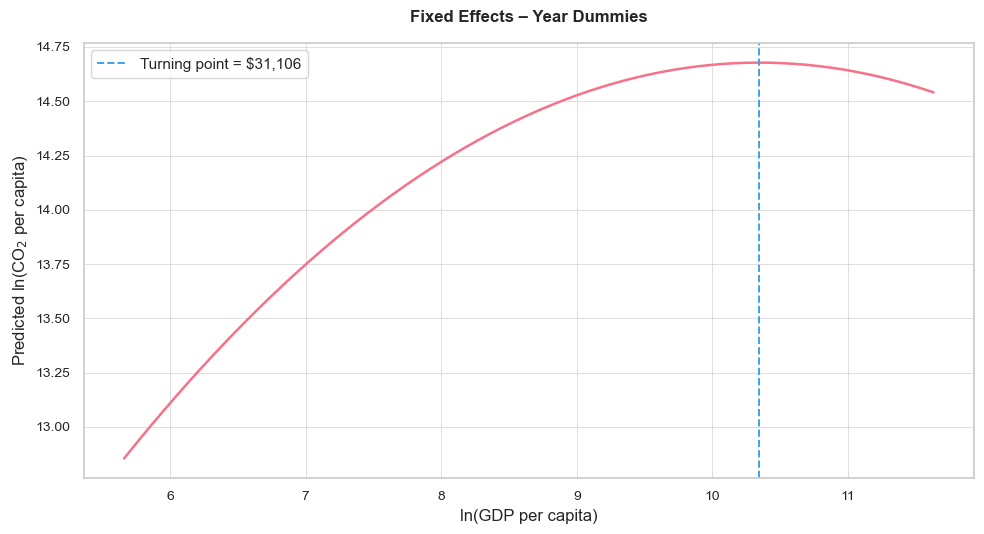

EKC Turning Point using variables [d_lnGDP, d_lnGDP_sq]:
  Turning point (log GDP): 10.9244
  Turning point (GDP per capita): $55,515



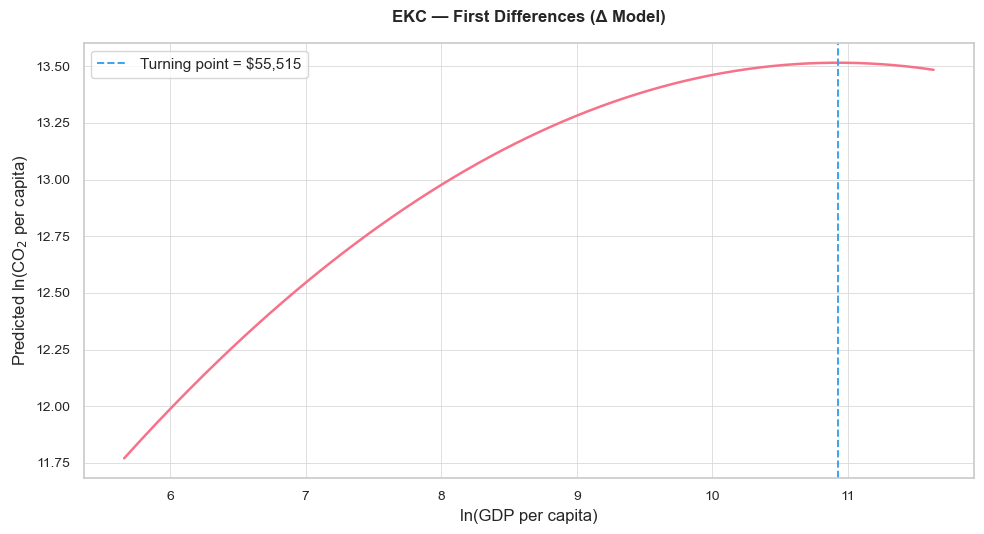

In [85]:
def plot_ekc(model, panel_df, turning_log_gdp, turning_gdp_pc,
             var_gdp="lnGDP", var_gdp_sq="lnGDP_sq",
             title_prefix="Environmental Kuznets Curve"):
    """
    Creates an EKC plot that works for both FE-TWFE (levels)
    and FE-FD (first differences).
    """

    # 1. Detect variable names
    params = model.params.index.tolist()

    # Switch to differenced vars if needed
    if var_gdp not in params:
        var_gdp = f"d_{var_gdp}"
    if var_gdp_sq not in params:
        var_gdp_sq = f"d_{var_gdp_sq}"

    # 2. Build lnGDP range
    base_var = var_gdp.replace("d_", "")  # strip differencing for level range
    lnGDP_min = panel_df[base_var].min()
    lnGDP_max = panel_df[base_var].max()
    lnGDP_range = np.linspace(lnGDP_min, lnGDP_max, 200)

    # 3. Prediction DataFrame
    # Get control variables in model
    # controls = [v for v in params if v not in [var_gdp, var_gdp_sq, "const"] and not v.startswith("d_20")]
    # controls = slope variables = everything except GDP, GDP_sq, intercept, and year FE
    # Controls = slope variables, excluding GDP terms, constant, and ALL year FE (level or differenced)
    controls = [
        v for v in params
        if v not in [var_gdp, var_gdp_sq, "const"]
        and not str(v).isdigit()         # excludes 2001, 2002... (TWFE)
        and not str(v)[2:].isdigit()     # excludes d_2002, d_2003... (FD)
    ]

    mean_vals = {}
    for c in controls:
        base_c = c[2:] if c.startswith("d_") else c
        mean_vals[c] = panel_df[base_c].mean()

    pred_df = pd.DataFrame({
        var_gdp: lnGDP_range,
        var_gdp_sq: lnGDP_range**2,
        **mean_vals
    })

    # 4. Predicted lnCO2
    beta = model.params

    pred_df["pred_lnCO2"] = 0
    for col in pred_df.columns:
        if col in beta.index:
            pred_df["pred_lnCO2"] += beta[col] * pred_df[col]

    # 5. Plot
    sns.set_theme(style="whitegrid")
    plt.rc('grid', color='0.85', linestyle='-', linewidth=0.6)

    curve_color = sns.color_palette("husl", 1)[0]
    tp_color = sns.color_palette("husl", 3)[2]

    fig = plt.figure(figsize=(10, 5.5))
    ax = fig.add_subplot(1, 1, 1)

    ax.plot(
        lnGDP_range,
        pred_df["pred_lnCO2"],
        color=curve_color,
        linewidth=1.8
    )

    # Turning point vertical line
    ax.axvline(
        turning_log_gdp,
        color=tp_color,
        linestyle="--",
        linewidth=1.4,
        label=f"Turning point = ${turning_gdp_pc:,.0f}"
    )

    ax.set_xlabel("ln(GDP per capita)")
    ax.set_ylabel("Predicted ln(CO$_2$ per capita)")
    ax.set_title(f"{title_prefix}", weight="bold", fontsize=12, pad=15)
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

log_tp, gdp_tp = compute_ekc_turning_point(fe_tw)
plot_ekc(fe_tw, panel_df_model, log_tp, gdp_tp,
         title_prefix="Fixed Effects – Year Dummies")

log_tp_fd, gdp_tp_fd = compute_ekc_turning_point(fe_fd)
plot_ekc(fe_fd, panel_df_model, log_tp_fd, gdp_tp_fd,
         title_prefix="EKC — First Differences (Δ Model)")

##### 7.3 Year Fixed Effects Plot

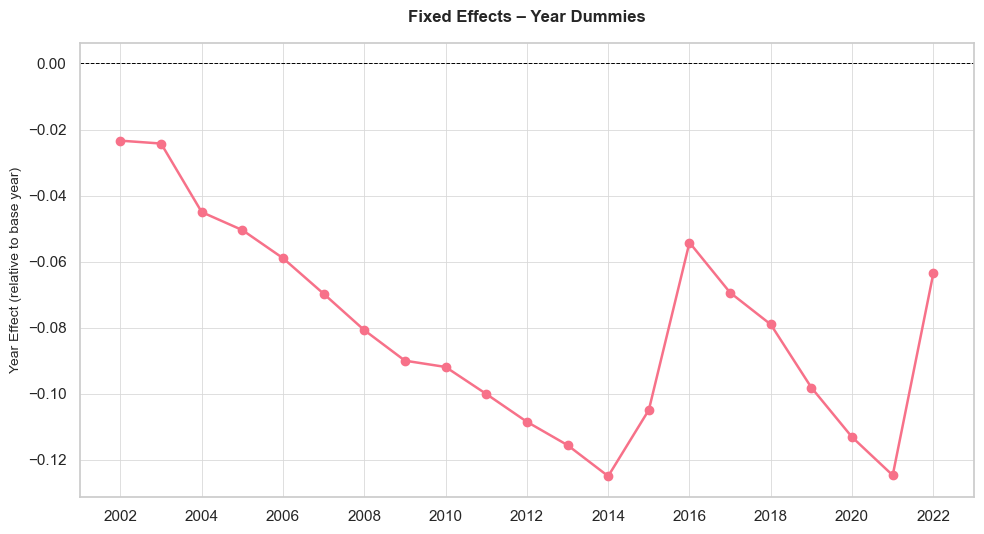

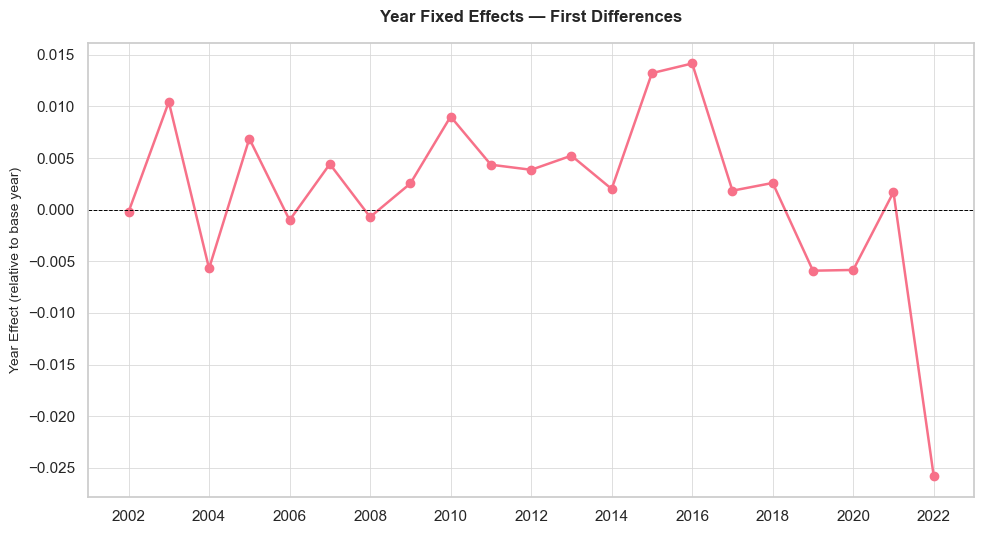

In [86]:
def plot_year_fe(model, title="Year Fixed Effects Plot"):
    """
    Plots year fixed effects for both:
    - TWFE models (year FE stored as integers)
    - FD models  (year FE stored as strings 'd_2002')
    """

    # Extract year FE coefficients
    year_coefs = model.params[
        model.params.index.map(
            lambda x: (
                isinstance(x, int)          # TWFE: 2002, 2003, ...
                or (isinstance(x, str) 
                    and x.startswith("d_") 
                    and x[2:].isdigit())    # FD: 'd_2002'
            )
        )
    ]

    # Remove base year 2001 if present
    year_coefs = year_coefs.drop(labels=[2001], errors="ignore")

    # Convert index to numeric year values
    years = np.array([
        int(x) if isinstance(x, int) else int(x[2:]) 
        for x in year_coefs.index
    ])

    sns.set_theme(style="whitegrid")
    plt.rc('grid', color='0.85', linestyle='-', linewidth=0.6)

    plt.figure(figsize=(10, 5.5))
    
    # Sort by year to avoid jagged ordering + float axis artifacts
    sort_idx = np.argsort(years)
    years = years[sort_idx]
    vals = year_coefs.values[sort_idx]

    plt.plot(years, vals, marker="o",
             linewidth=1.8, color=sns.color_palette("husl", 1)[0])
    
    plt.xticks(years[::2])

    plt.axhline(0, color="black", linestyle="--", linewidth=0.7)

    plt.title(title, weight="bold", fontsize=12, pad=15)
    plt.xlabel(None)
    plt.ylabel("Year Effect (relative to base year)", fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_year_fe(fe_tw, title="Fixed Effects – Year Dummies")
plot_year_fe(fe_fd, title="Year Fixed Effects — First Differences")

In [87]:
def compute_ekc_turning_point(model, var_gdp="lnGDP", var_gdp_sq="lnGDP_sq"):
    """
    Computes the EKC turning point for any model (FE-TWFE or FD-FE).
    Automatically works for differenced models if variables are prefixed with 'd_'.
    """

    # 1. Identify actual variable names in model params
    params = model.params.index.tolist()

    # Prefer exact match; otherwise allow differenced version
    if var_gdp not in params:
        var_gdp = f"d_{var_gdp}"
    if var_gdp_sq not in params:
        var_gdp_sq = f"d_{var_gdp_sq}"

    # 2. Extract coefficients
    b1 = model.params[var_gdp]
    b2 = model.params[var_gdp_sq]

    # 3. Turning point (log scale)
    turning_log_gdp = -b1 / (2 * b2)

    # 4. Convert to level GDP
    turning_gdp_pc = np.exp(turning_log_gdp)

    # 5. Print
    print(f"EKC Turning Point using variables [{var_gdp}, {var_gdp_sq}]:")
    print(f"  Turning point (log GDP): {turning_log_gdp:.4f}")
    print(f"  Turning point (GDP per capita): ${turning_gdp_pc:,.0f}\n")

    return turning_log_gdp, turning_gdp_pc

# Helper: Count observations + countries above turning point
# Works for both TWFE and FD models
def count_above_turning_point(df, turning_log_gdp):
    """
    Counts observations and countries with lnGDP (or d_lnGDP) above the turning point.
    Automatically detects differenced vs levels and prints the list of countries.
    """

    # Detect variable name (lnGDP or d_lnGDP)
    gdp_cols = [col for col in df.columns if col.endswith("lnGDP")]
    if len(gdp_cols) == 0:
        raise ValueError("No GDP variable found.")
    gdp_var = gdp_cols[0]

    # Indicator: above turning point
    df["above_tp"] = df[gdp_var] > turning_log_gdp

    obs_above = df["above_tp"].sum()
    total_obs = len(df)
    share = obs_above / total_obs * 100

    # Unique countries logic
    countries_list = []
    
    if isinstance(df.index, pd.MultiIndex):
        # If index is preserved
        countries_list = df[df["above_tp"]].index.get_level_values(0).unique().tolist()
    else:
        # If reset_index() was used, check for standard column names
        # 'Country Name' is standard WDI, 'country_name' is fallback
        c_col = 'Country Name' if 'Country Name' in df.columns else 'country_name'
        
        if c_col in df.columns:
            countries_list = df.loc[df["above_tp"], c_col].unique().tolist()
        else:
            print("Warning: Could not identify country column for listing.")

    countries_list.sort()
    country_count = len(countries_list)

    print(f"Observations above turning point: {obs_above:,} ÷ {total_obs:,} = {share:.2f}%")
    print(f"Countries that ever exceed turning point: {country_count}")
    print(f"List of countries: {', '.join(countries_list)}\n")

    return obs_above, share, country_count

# Helper: Sensitivity checks (top-1% GDP drop, non-OECD drop)
# Automatically refits same model type (TWFE or FD)
def sensitivity_checks(model, df, model_type="twfe"):
    """
    Sensitivity tests for TWFE and FD models:
      - Drop top 1% GDP
      - Drop OECD countries
    Rebuilds the model using the same regressors as original.
    """

    # Detect GDP variable (lnGDP or d_lnGDP)
    gdp_cols = [col for col in df.columns if col.endswith("lnGDP")]
    gdp_var = gdp_cols[0]

    # 1. Drop top 1% GDP observations
    gdp_cut = df[gdp_var].quantile(0.99)
    df_trim = df[df[gdp_var] <= gdp_cut]

    # Reconstruct X for TWFE
    if model_type == "twfe":
        y_trim = df_trim["lnCO2"]
        X_trim = df_trim[[
            "lnGDP", "lnGDP_sq", "lnEnergy", "lnUrban",
            "lnTrade", "renewable_pct", "fossil_fuel_pct",
            "lnPopDensity", "industry_value_added_pct_gdp"
        ]]
        fe_trim = PanelOLS(
            y_trim, X_trim, entity_effects=True, time_effects=True
        ).fit()
    else:
        # FD version
        y_trim = df_trim["d_lnCO2"]
        X_trim = df_trim[[
            "d_lnGDP", "d_lnGDP_sq", "d_lnEnergy", "d_lnUrban",
            "d_lnTrade", "renewable_pct", "fossil_fuel_pct",
            "d_lnPopDensity", "industry_value_added_pct_gdp"
        ]]
        fe_trim = PanelOLS(
            y_trim, X_trim, entity_effects=True
        ).fit()

    tp_log_trim, tp_gdp_trim = compute_ekc_turning_point(fe_trim)
    print(f"Turning point (trimmed sample): ${tp_gdp_trim:,.0f}\n")

    # 2. Drop OECD countries
    oecd_list = [
        "United States", "Canada", "United Kingdom", "Germany", "France", "Japan",
        "Australia", "New Zealand", "Sweden", "Norway", "Denmark", "Finland",
        "Netherlands", "Belgium", "Italy", "Spain", "Portugal", "Switzerland",
        "Austria", "Ireland", "Luxembourg", "Iceland", "Korea, Rep."
    ]

    df_no = df[~df.index.get_level_values(0).isin(oecd_list)]

    if model_type == "twfe":
        y_no = df_no["lnCO2"]
        X_no = df_no[[
            "lnGDP", "lnGDP_sq", "lnEnergy", "lnUrban",
            "lnTrade", "renewable_pct", "fossil_fuel_pct",
            "lnPopDensity", "industry_value_added_pct_gdp"
        ]]
        fe_no = PanelOLS(
            y_no, X_no, entity_effects=True, time_effects=True
        ).fit()
    else:
        y_no = df_no["d_lnCO2"]
        X_no = df_no[[
            "d_lnGDP", "d_lnGDP_sq", "d_lnEnergy", "d_lnUrban",
            "d_lnTrade", "renewable_pct", "fossil_fuel_pct",
            "d_lnPopDensity", "industry_value_added_pct_gdp"
        ]]
        fe_no = PanelOLS(
            y_no, X_no, entity_effects=True
        ).fit()

    tp_log_no, tp_gdp_no = compute_ekc_turning_point(fe_no)
    print(f"Turning point (non-OECD): ${tp_gdp_no:,.0f}\n")

    return {
        "trimmed_tp": tp_gdp_trim,
        "non_oecd_tp": tp_gdp_no
    }

print(f"1. Turning point for Two-Way FE model:\n{'-' * 38}")
tp_log_tw, tp_gdp_tw = compute_ekc_turning_point(fe_tw)

print(f"2. Turning point for First Difference FE model:\n{'-' * 47}")
tp_log_fd, tp_gdp_fd = compute_ekc_turning_point(fe_fd)

print(f"3. Count above turning point for Two-Way FE model:\n{'-' * 50}")
count_above_turning_point(panel_df_model.reset_index(), tp_log_tw)

print(f"4. Count above turning point for First Difference FE model:\n{'-' * 59}")
count_above_turning_point(df_fd.reset_index(), tp_log_fd)

print(f"5. Sensitivity checks for Two-Way FE model:\n{'-' * 43}")
sensitivity_checks(fe_tw, panel_df_model, model_type="twfe")

print(f"6. Sensitivity checks for First Difference FE model:\n{'-' * 52}")
sensitivity_checks(fe_fd, df_fd, model_type="fd")

1. Turning point for Two-Way FE model:
--------------------------------------
EKC Turning Point using variables [lnGDP, lnGDP_sq]:
  Turning point (log GDP): 10.3452
  Turning point (GDP per capita): $31,106

2. Turning point for First Difference FE model:
-----------------------------------------------
EKC Turning Point using variables [d_lnGDP, d_lnGDP_sq]:
  Turning point (log GDP): 10.9244
  Turning point (GDP per capita): $55,515

3. Count above turning point for Two-Way FE model:
--------------------------------------------------
Observations above turning point: 520 ÷ 2,816 = 18.47%
Countries that ever exceed turning point: 28
List of countries: Australia, Austria, Belgium, Brunei Darussalam, Canada, Denmark, Finland, France, Germany, Hong Kong SAR, China, Iceland, Ireland, Israel, Italy, Japan, Korea, Rep., Kuwait, Luxembourg, Malta, Netherlands, New Zealand, Norway, Singapore, Sweden, Switzerland, United Arab Emirates, United Kingdom, United States

4. Count above turning poin

{'trimmed_tp': np.float64(192607.54668140764),
 'non_oecd_tp': np.float64(98073.41256749885)}

##### 7.4 Year Fixed Effects Plot (Normalized)

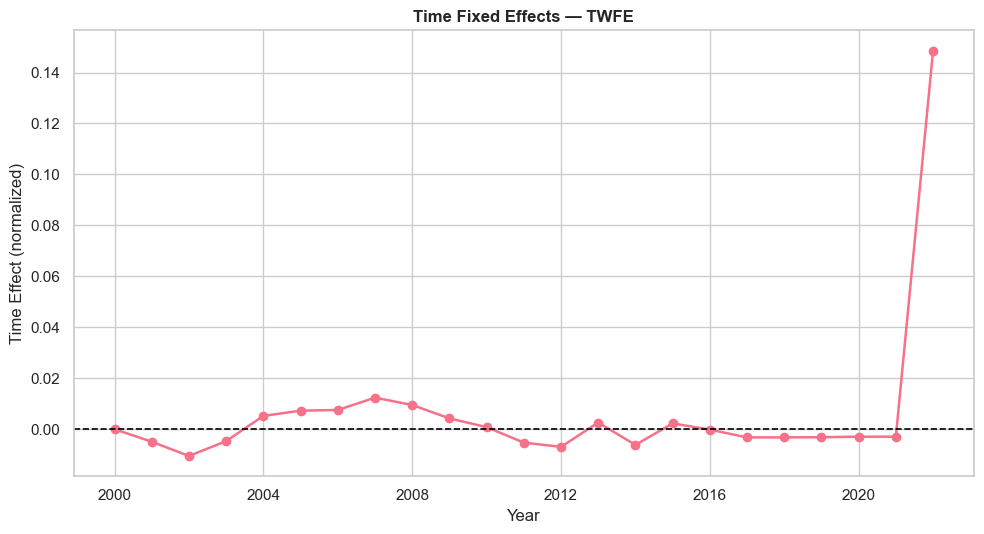

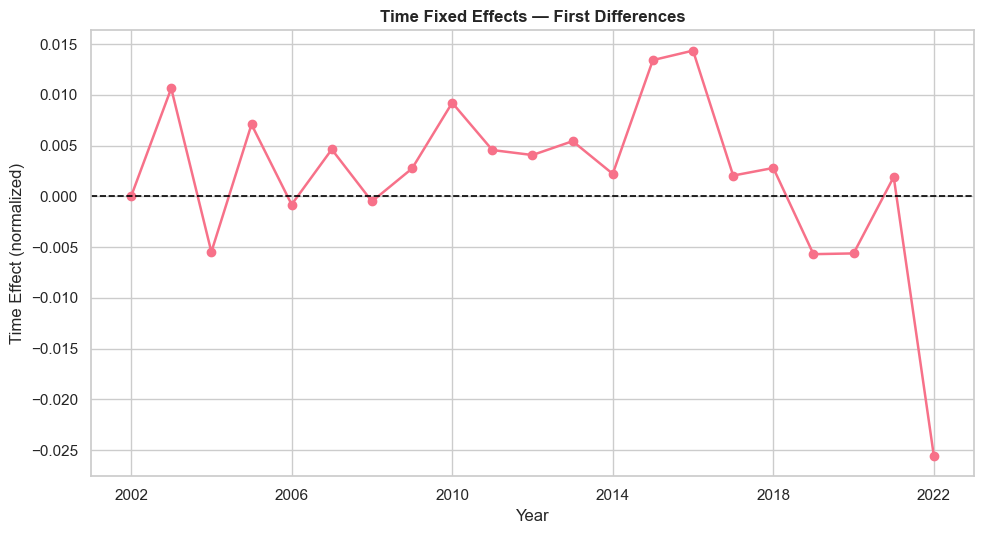

In [88]:
def plot_time_fe(model, title="Time Fixed Effects"):
    """
    Plots normalized time fixed effects for:
    - TWFE (PanelOLS) using estimated_effects
    - FD   (statsmodels OLS) using d_2002, d_2003, ... coefficients
    
    Normalized so base year = 0.
    """

    # 1: TWFE (PanelOLS) with estimated_effects
    if hasattr(model, "estimated_effects"):
        eff = model.estimated_effects["estimated_effects"]

        # Convert to dataframe
        df_eff = eff.reset_index(name="effect")

        # Group by year
        time_fe = (
            df_eff.groupby("year")["effect"]
            .mean()
            .to_frame("time_effect")
        )

        # Normalize relative to first available year
        base_year = time_fe.index.min()
        time_fe["norm"] = time_fe["time_effect"] - time_fe.loc[base_year, "time_effect"]

        years = time_fe.index
        values = time_fe["norm"].values

    # 2: FD (statsmodels OLS) using d_20xx coefficients
    else:
        params = model.params

        # Extract d_2002, d_2003, ...
        year_coefs = {
            int(k[2:]): v
            for k, v in params.items()
            if isinstance(k, str) and k.startswith("d_") and k[2:].isdigit()
        }

        years = sorted(year_coefs.keys())
        values = np.array([year_coefs[y] for y in years])

        # Normalize relative to first year
        values = values - values[0]

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 5.5))

    plt.plot(
        years,
        values,
        marker="o",
        linewidth=1.8,
        color=sns.color_palette("husl", 1)[0]
    )
    plt.xticks(years[::4])
    plt.axhline(0, linestyle="--", color="black", linewidth=1.2)

    plt.title(title, weight="bold")
    plt.xlabel("Year")
    plt.ylabel("Time Effect (normalized)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_time_fe(fe_tw, title="Time Fixed Effects — TWFE")
plot_time_fe(fe_fd, title="Time Fixed Effects — First Differences")

##### 7.5 Coefficient Plot

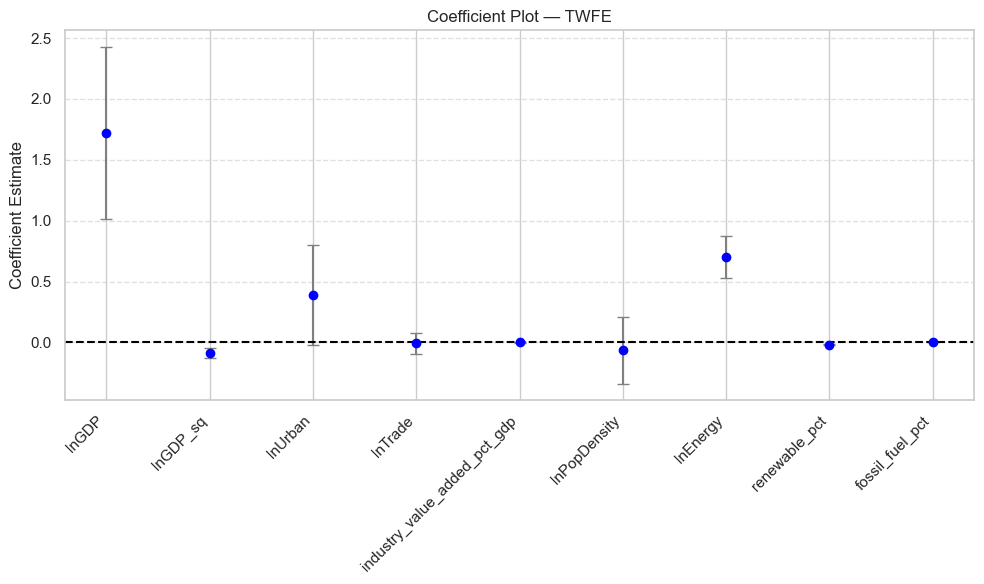

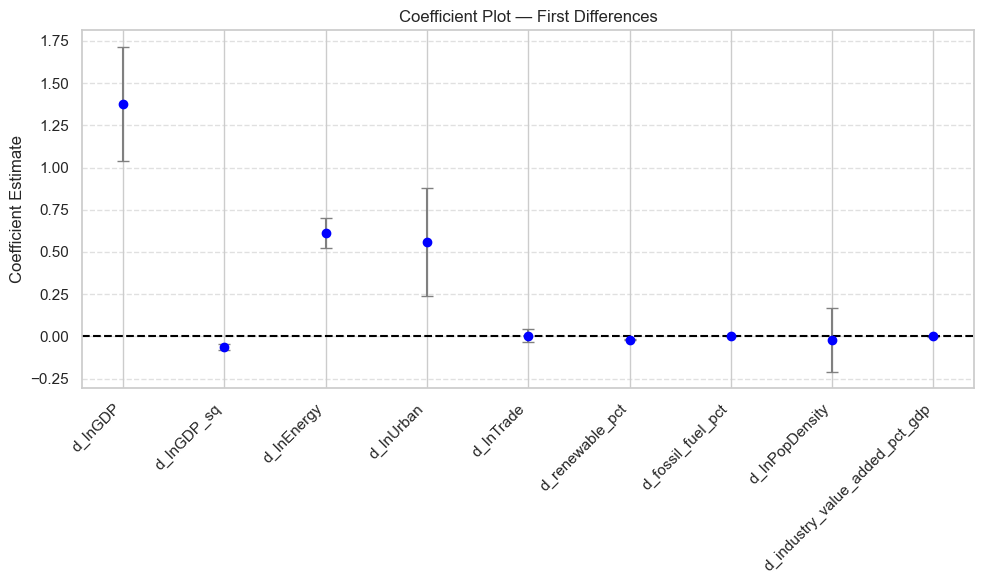

In [89]:
def plot_coef(model, title="Coefficient Plot"):
    """
    Plots slope coefficients with 95% CI for:
    - TWFE models (year FE = integers)
    - FD models  (year FE = 'd_2002', ...)

    Removes: constant, year FE, differenced year FE.
    """

    params = model.params
    se = model.std_errors

    # Identify slope coefficients
    slope_idx = [
        k for k in params.index
        if k != "const"
        and not (isinstance(k, int))                     # exclude TWFE year FE
        and not (isinstance(k, str) and k.startswith("d_") and k[2:].isdigit())  # exclude FD year FE
    ]

    # Extract coefficients and SE
    coef = params[slope_idx]
    se   = se[slope_idx]

    # 95% CI
    ci_lower = coef - 1.96 * se
    ci_upper = coef + 1.96 * se

    plt.figure(figsize=(10, 6))
    plt.errorbar(
        coef.index,
        coef.values,
        yerr=[coef.values - ci_lower, ci_upper - coef.values],
        fmt='o',
        color='blue',
        ecolor='gray',
        capsize=4
    )

    plt.axhline(0, color='black', linestyle='--')
    plt.xticks(rotation=45, ha='right')
    plt.title(title)
    plt.ylabel("Coefficient Estimate")
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_coef(fe_tw, title="Coefficient Plot — TWFE")
plot_coef(fe_fd, title="Coefficient Plot — First Differences")

##### 7.6 Actual vs Fitted Plot

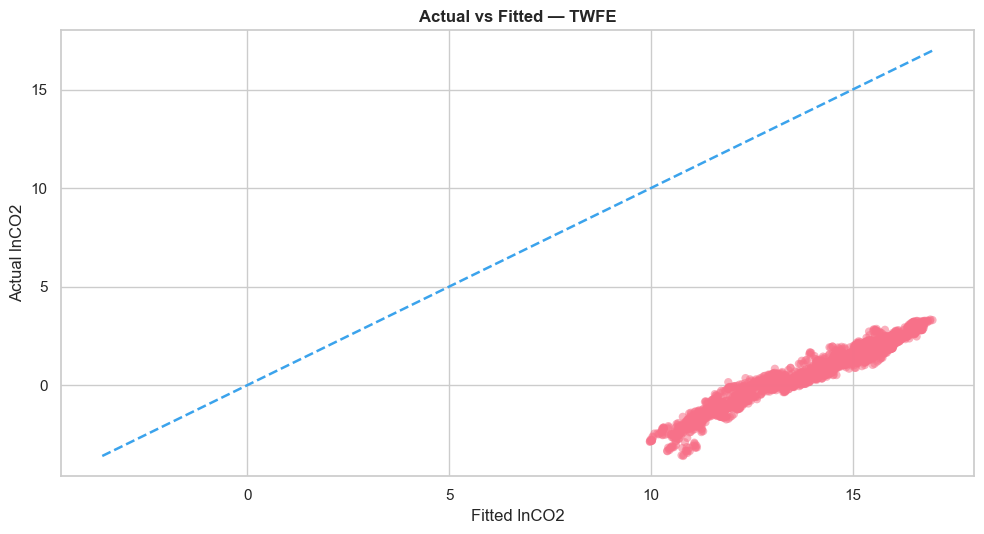

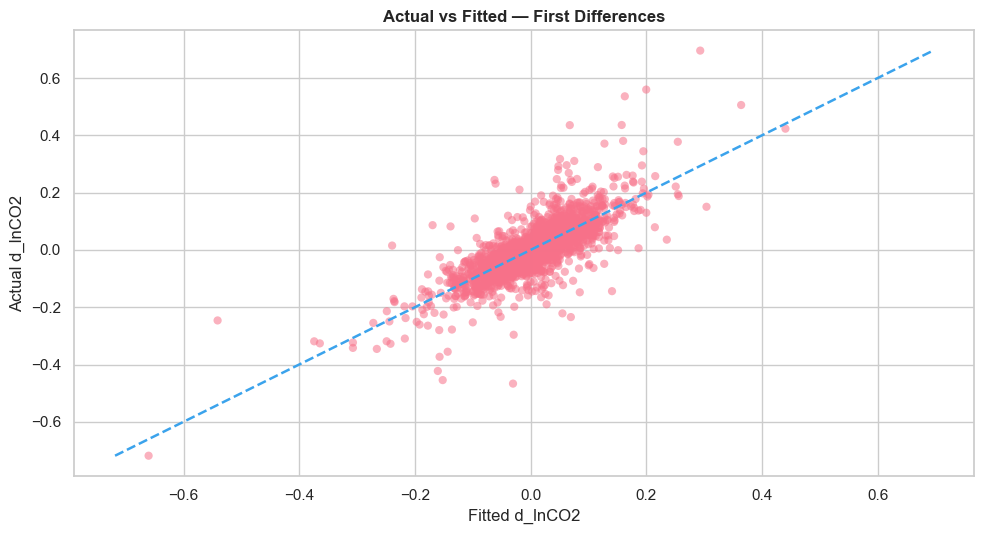

In [90]:
def plot_actual_vs_fitted(model, df, title="Actual vs Fitted"):

    # 1. Dependent variable name
    try:
        dep_var = model.model.dependent.vars[0]      # PanelOLS (TWFE)
    except AttributeError:
        dep_var = model.model.endog_names            # statsmodels OLS (FD)

    y = df[dep_var]

    # 2. Fitted values
    try:
        fitted_vals = model.fitted_values            # PanelOLS
    except AttributeError:
        fitted_vals = model.fittedvalues             # statsmodels OLS

    # 3. Align indices
    common_idx = fitted_vals.index.intersection(y.index)
    y_plot = y.loc[common_idx]
    fitted_plot = fitted_vals.loc[common_idx]

    # 4. Ensure 1D Series
    fitted_plot = pd.Series(fitted_plot.squeeze(), index=fitted_plot.index)

    # 5. Axis limits
    min_val = min(float(y_plot.min()), float(fitted_plot.min()))
    max_val = max(float(y_plot.max()), float(fitted_plot.max()))

    # 6. Plot
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 5.5))

    plt.scatter(
        fitted_plot,
        y_plot,
        alpha=0.55,
        s=35,
        color=sns.color_palette("husl", 1)[0],
        edgecolor="none"
    )

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        "--",
        linewidth=1.8,
        color=sns.color_palette("husl", 3)[2]
    )

    plt.xlabel(f"Fitted {dep_var}")
    plt.ylabel(f"Actual {dep_var}")
    plt.title(title, weight="bold")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_actual_vs_fitted(fe_tw, panel_df_model,
                      title="Actual vs Fitted — TWFE")
plot_actual_vs_fitted(fe_fd, df_fd,
                      title="Actual vs Fitted — First Differences")

##### 7.7 First-order Autocorrelation in Idiosyncratic Errors

In [91]:
def compute_ar1(model, df):
    """
    Computes AR(1) serial correlation of residuals for:
    - TWFE (PanelOLS): model.resids (MultiIndex)
    - FD   (statsmodels OLS): model.resid (index aligned with df)
    """

    # 1. Extract residuals for both model types
    try:
        # PanelOLS residuals: MultiIndex (country, year)
        resid = model.resids
    except AttributeError:
        # statsmodels OLS residuals: Series aligned with df
        resid = pd.Series(model.resid, index=df.index)

    # 2. Convert to DataFrame
    df_r = resid.reset_index()
    df_r = df_r.rename(columns={0: "resid", "residual": "resid"})

    # TWFE has ['country_name','year']; FD has them inside df
    if "country_name" not in df_r.columns:
        df_r["country_name"] = df.reset_index()["country_name"]
        df_r["year"] = df.reset_index()["year"]

    df_r = df_r.sort_values(["country_name", "year"])

    # 3. Lag residuals within country
    df_r["resid_lag"] = df_r.groupby("country_name")["resid"].shift(1)

    # 4. Drop missing lag rows
    df_r2 = df_r.dropna(subset=["resid", "resid_lag"])

    # 5. Compute AR(1) correlation
    rho1 = df_r2["resid"].corr(df_r2["resid_lag"])

    print(f"AR(1) Serial Correlation ρ₁ = {rho1:.4f}")
    return rho1

print("For Two-way FE:")
print(compute_ar1(fe_tw, panel_df_model))
print("\nFor First-difference FE:")
print(compute_ar1(fe_fd, df_fd))

For Two-way FE:
AR(1) Serial Correlation ρ₁ = 0.8777
0.8776908276955868

For First-difference FE:
AR(1) Serial Correlation ρ₁ = 0.0286
0.02861385042312334


##### 7.8 Woolridge Test for Serial Correlation

In [92]:
# Wooldridge Test for Serial Correlation (applied to any model residual series)
def wooldridge_test(df_resid, unit_var="country_name", time_var="year"):
    # df_resid must have columns: [unit_var, time_var, "residual"]

    # sort
    df_resid = df_resid.sort_values([unit_var, time_var])

    # create first-differenced residuals
    df_resid["resid_lag"] = df_resid.groupby(unit_var)["residual"].shift(1)
    df_resid["d_resid"] = df_resid.groupby(unit_var)["residual"].diff()
    df_resid["d_resid_lag"] = df_resid.groupby(unit_var)["d_resid"].shift(1)

    # drop missing
    df_resid = df_resid.dropna(subset=["d_resid", "d_resid_lag"])

    # run regression Δu on Δu_lag
    y = df_resid["d_resid"]
    X = sm.add_constant(df_resid["d_resid_lag"])
    reg = sm.OLS(y, X).fit()

    return {
        "F_stat": float(reg.fvalue),
        "p_value": float(reg.f_pvalue),
        "n": len(df_resid)
    }

# Interpretation
def interpret_wooldridge(name, result):
    if result["p_value"] < 0.05:
        print(f"{name}: Reject H0: serial correlation detected.")
    else:
        print(f"{name}: Do not reject H0: no evidence of serial correlation.")

# 1. Wooldridge test for Two-Way FE model
res_tw = fe_tw.resids.reset_index().rename(columns={0: "residual"})
wt_tw = wooldridge_test(res_tw)
print("Two-Way FE Wooldridge Test:", wt_tw)
interpret_wooldridge("Two-Way FE", wt_tw)

# 2. Wooldridge test for First-Difference FE model
res_fd = fe_fd.resid.reset_index().rename(columns={0: "residual"})
wt_fd = wooldridge_test(res_fd)
print("\nFirst-Difference FE Wooldridge Test:", wt_fd)
interpret_wooldridge("First-Difference FE", wt_fd)

Two-Way FE Wooldridge Test: {'F_stat': 0.6593575626546021, 'p_value': 0.4168628107282195, 'n': 2546}
Two-Way FE: Do not reject H0: no evidence of serial correlation.

First-Difference FE Wooldridge Test: {'F_stat': 902.5120914541722, 'p_value': 1.105291012786613e-168, 'n': 2411}
First-Difference FE: Reject H0: serial correlation detected.


##### 7.9 Breusch-Pagan Test for Heteroskedasticity

In [93]:
# Residuals from pooled OLS
resid = pooled_ols.resids

# Rebuild X with the same variables used in pooled OLS AND add constant explicitly
X_bp = sm.add_constant(panel_df_model[[
    "lnGDP", "lnGDP_sq", "lnEnergy", "lnUrban", "lnTrade",
    "renewable_pct", "fossil_fuel_pct", "lnPopDensity",
    "industry_value_added_pct_gdp"
]])

# Run Breusch–Pagan test
bp_stat, bp_pvalue, f_stat, f_pvalue = het_breuschpagan(resid, X_bp)

print("Breusch–Pagan Test for Heteroskedasticity")
print(f"BP Statistic: {bp_stat:.4f}")
print(f"BP p-value:   {bp_pvalue:.3e}")
print(f"F-Statistic:  {f_stat:.4f}")
print(f"F p-value:    {f_pvalue:.3e}")

if bp_pvalue < 0.05:
    print("\nConclusion: Reject H0 → Heteroskedasticity detected.")
    print("Justification: Use cluster-robust standard errors (already applied in FE/TWFE).")
else:
    print("\nConclusion: Fail to reject H0 → No heteroskedasticity detected.")

Breusch–Pagan Test for Heteroskedasticity
BP Statistic: 480.3482
BP p-value:   9.253e-98
F-Statistic:  64.1200
F p-value:    2.044e-107

Conclusion: Reject H0 → Heteroskedasticity detected.
Justification: Use cluster-robust standard errors (already applied in FE/TWFE).
